# Практика 1

## 1. Загрузка изображения

In [12]:
def showpic(image, text):
    plt.imshow(image, cmap='gray')
    plt.title(text)
    plt.show()

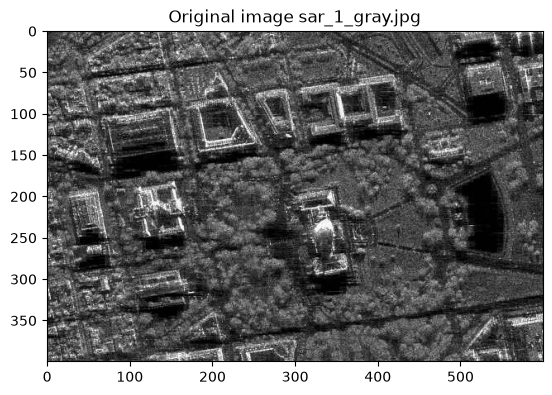

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_gray_1 = cv2.imread('source/sar_1_gray.jpg')
image_gray_1 = cv2.cvtColor(image_gray_1, cv2.COLOR_BGR2GRAY)

showpic(image_gray_1, 'Original image sar_1_gray.jpg')

## 2. Гистограмма

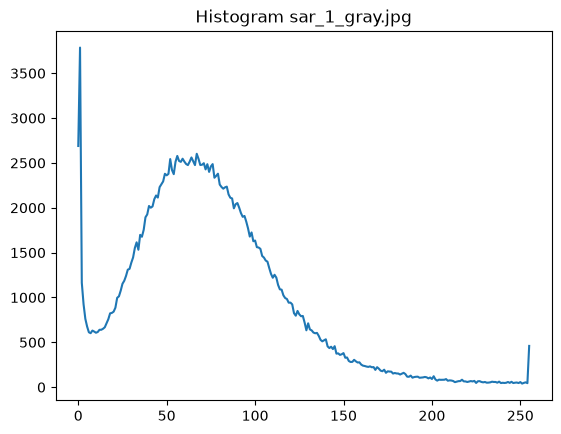

In [14]:
hist = cv2.calcHist([image_gray_1], [0], None, [256], [0,256])
plt.plot(hist)
plt.title('Histogram sar_1_gray.jpg')
plt.show()

## 3 Гамма-коррекция

In [15]:
def gamma_correction(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

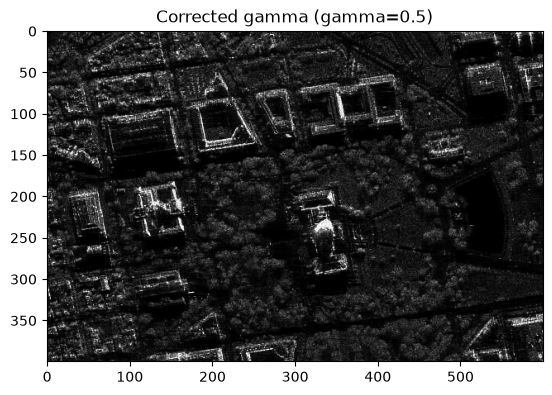

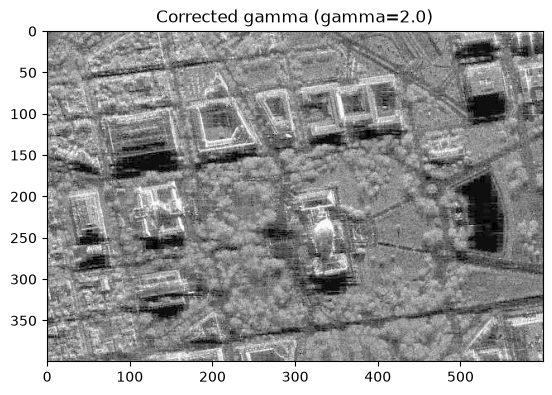

In [16]:
gamma_low = 0.5

gamma_high = 2.0

corrected_low = gamma_correction(image_gray_1, gamma_low)
corrected_high = gamma_correction(image_gray_1, gamma_high)

showpic(corrected_low, f'Corrected gamma (gamma={gamma_low})')
showpic(corrected_high, f'Corrected gamma (gamma={gamma_high})')

## 4. Сравнение MSE, SSIM

Сравнение с gamma=0.5: MSE = 2383.76, SSIM = 0.5270


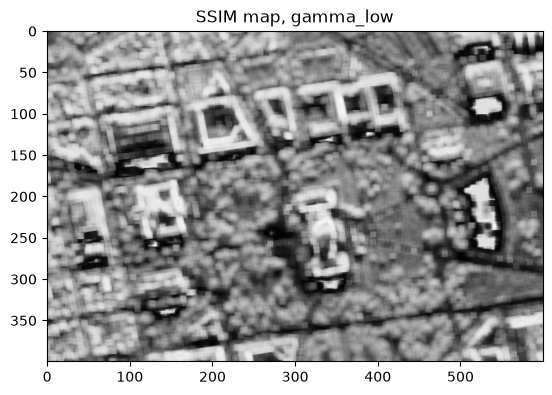

Сравнение с gamma=2.0: MSE = 3250.43, SSIM = 0.7875


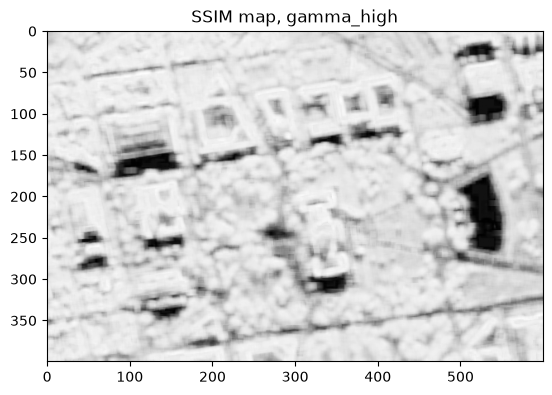

In [17]:
from skimage.metrics import structural_similarity, mean_squared_error

mse_low = mean_squared_error(image_gray_1, corrected_low)
(ssim_low, diff_low) = structural_similarity(image_gray_1, corrected_low, full=True)
print(f"Сравнение с gamma={gamma_low}: MSE = {mse_low:.2f}, SSIM = {ssim_low:.4f}")
diff_low = (diff_low * 255).astype("uint8")
showpic(diff_low, "SSIM map, gamma_low")

mse_high = mean_squared_error(image_gray_1, corrected_high)
(ssim_high, diff_high) = structural_similarity(image_gray_1, corrected_high, full=True)
print(f"Сравнение с gamma={gamma_high}: MSE = {mse_high:.2f}, SSIM = {ssim_high:.4f}")
diff_high = (diff_high * 255).astype("uint8")
showpic(diff_high, "SSIM map, gamma_high")

## 5. Статистическая коррекция

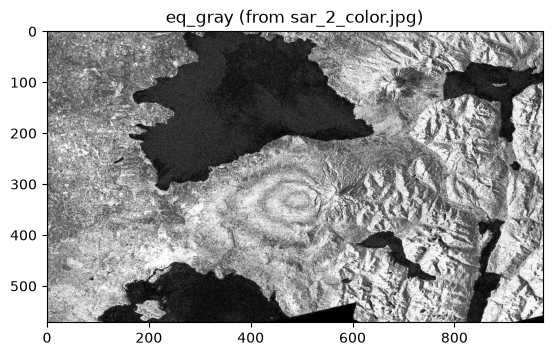

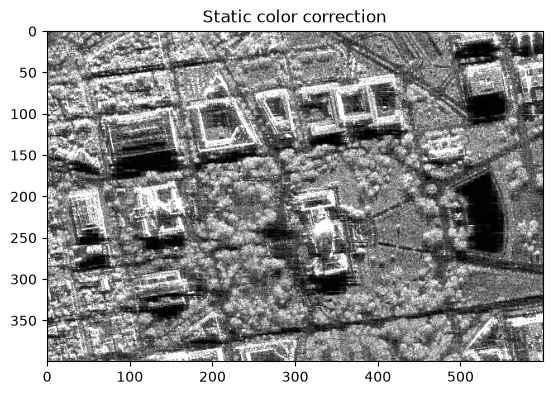

In [18]:
image_2 = cv2.imread('source/sar_2_color.jpg')
image_gray_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)
eq_gray = cv2.equalizeHist(image_gray_2)

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

mean_orig = image_gray_1.mean()
std_orig = image_gray_1.std()

corrected_stat = (image_gray_1 - mean_orig) * (std_eq / std_orig) + mean_eq
corrected_stat = np.clip(corrected_stat, 0, 255).astype(np.uint8)

showpic(eq_gray, 'eq_gray (from sar_2_color.jpg)')
showpic(corrected_stat, 'Static color correction')

## 6. Пороговая фильтрация

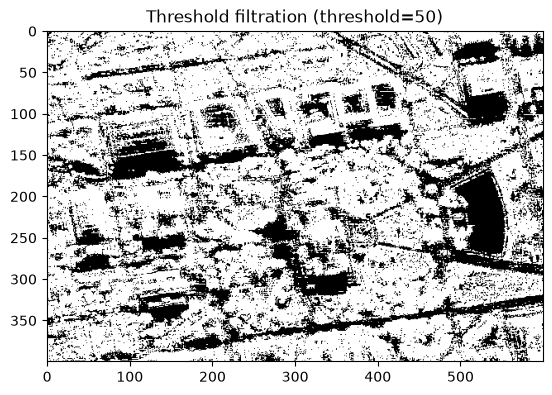

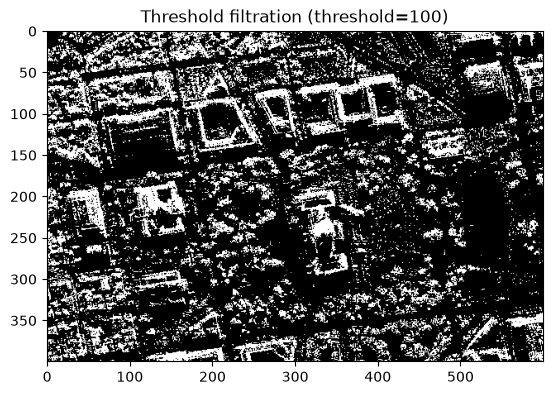

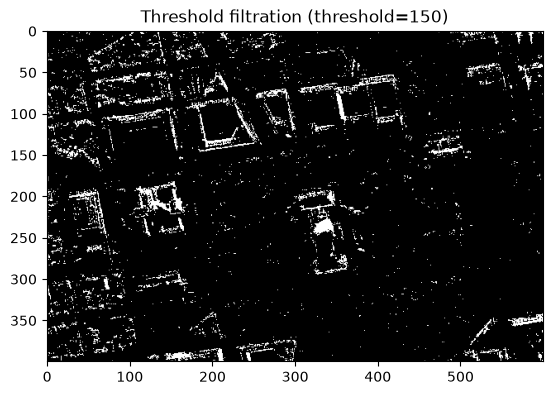

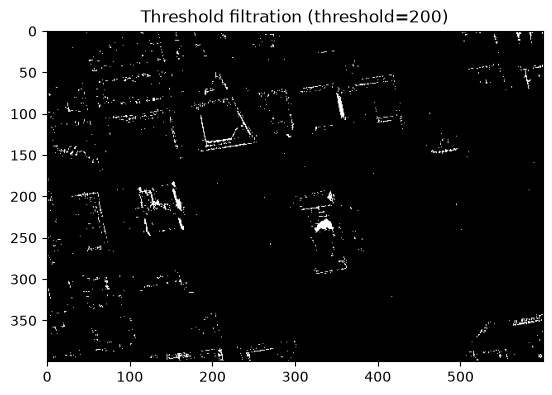

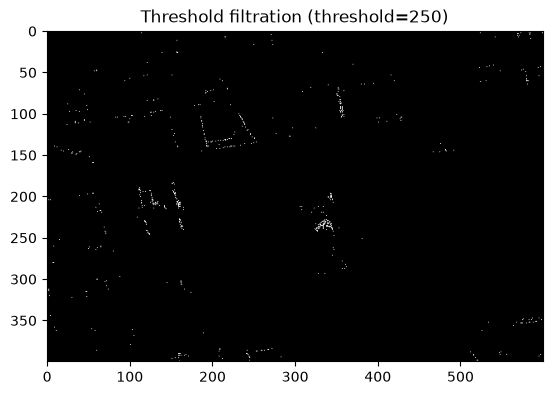

In [19]:
thresholds = [50, 100, 150, 200, 250]
for t in thresholds:
    _, thresh_img = cv2.threshold(image_gray_1, t, 255, cv2.THRESH_BINARY)
    showpic(thresh_img, f'Threshold filtration (threshold={t})')